# Assignment 3 — Phase 2 & 3 (Rohan Chaudhary)

**Self-contained notebook** — all model code defined in §6.

| | Model 1 (Phase 2) | Model 2 (Phase 3) |
|---|---|---|
| Encoder | **EfficientNet-B3** spatial 7×7 | **VGG-16-BN** global 512-d |
| Decoder | **Transformer** (cross-attention) | **2-layer GRU** + attention |
| Extra | Spatial feature dropout | Dropout + beam search |

**Phase 2 → Phase 3 progression:** Model 1 establishes a Transformer baseline with EfficientNet-B3 spatial features. Model 2 explores a simpler VGG-16-BN + GRU architecture, showing that architectural choices significantly impact performance and motivating further study.

Prerequisites: Phase 1 `artefacts/`, `val/`, annotations.

## 0. Imports and configuration

## 1. Vocabulary

In [1]:
import re, json, pickle, random, math
from pathlib import Path
from typing import Dict, List, Tuple, Optional

import numpy as np
import pandas as pd
%matplotlib inline
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence
import torchvision.transforms as transforms
import torchvision.models as models
from torchvision.models import (
    VGG16_BN_Weights, vgg16_bn,
    EfficientNet_B3_Weights, efficientnet_b3,
)
from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction

#  Reproducibility 
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

def get_device():
    if torch.cuda.is_available():   return torch.device("cuda")
    if getattr(torch.backends, "mps", None) and torch.backends.mps.is_available():
        return torch.device("mps")
    return torch.device("cpu")

DEVICE = get_device()
USE_PIN_MEMORY = DEVICE.type == "cuda"

if DEVICE.type == "mps":
    import os; os.environ.setdefault("PYTORCH_ENABLE_MPS_FALLBACK", "1")

#  Paths 
PROJECT_DIR     = Path(".").resolve()
DATA_DIR        = PROJECT_DIR
IMAGE_DIR       = DATA_DIR / "val"
ANNOTATIONS_PATH= DATA_DIR / "annotations" / "val.json"
ARTEFACTS_DIR   = DATA_DIR / "artefacts"
RESULTS_DIR     = DATA_DIR / "results"
CHECKPOINTS_DIR = DATA_DIR / "checkpoints"
RESULTS_DIR.mkdir(exist_ok=True)
CHECKPOINTS_DIR.mkdir(exist_ok=True)

#  Shared hyperparameters 
MIN_WORD_FREQ   = 5
MAX_CAPTION_LEN = 50
BATCH_SIZE      = 32
NUM_WORKERS     = 0
BEAM_WIDTH      = 5
MAX_DECODE_LEN  = 50

#  Run control flags 
QUICK_TEST            = False
SKIP_MODEL1_TRAINING  = True
FORCE_RETRAIN_M1      = False
FORCE_RETRAIN_M2      = False
MAX_BLEU_IMAGES       = None     
RUN_GREEDY_BLEU       = False

# Stale checkpoint cleanup
for _flag, _name in [(FORCE_RETRAIN_M1, "model1_best.pt"),
                     (FORCE_RETRAIN_M2, "model2_best.pt")]:
    _ck = CHECKPOINTS_DIR / _name
    if _flag and _ck.exists():
        _ck.unlink(); print(f"Removed stale: {_name}")

def verify_project_layout():
    errors = []
    if not IMAGE_DIR.is_dir() or not any(IMAGE_DIR.glob("*.jpg")):
        errors.append(f"Image folder missing or empty: {IMAGE_DIR}")
    if not ANNOTATIONS_PATH.is_file():
        errors.append(f"Annotations missing: {ANNOTATIONS_PATH}")
    for name in ("vocab.pkl","splits.json","id_to_tokens.json","metadata.json"):
        if not (ARTEFACTS_DIR / name).is_file():
            errors.append(f"Run Phase 1 first — missing artefacts/{name}")
    if errors: raise FileNotFoundError("\n".join(errors))
    print("Preflight OK: data + Phase 1 artefacts found.")

try:
    import nltk; nltk.download("punkt", quiet=True)
except Exception: pass

print(f"Device:  {DEVICE}")
print(f"Results: {RESULTS_DIR}")
if QUICK_TEST: print("QUICK_TEST=True → 1 epoch only")

Device:  mps
Results: /Users/rohanchaudhary/projects/DL_AT3/results


[nltk_data] Error loading punkt: <urlopen error [SSL:
[nltk_data]     CERTIFICATE_VERIFY_FAILED] certificate verify failed:
[nltk_data]     unable to get local issuer certificate (_ssl.c:1000)>


In [2]:
class Vocabulary:
    PAD_TOKEN, START_TOKEN, END_TOKEN, UNK_TOKEN = "<PAD>","<START>","<END>","<UNK>"
    PAD_IDX, START_IDX, END_IDX, UNK_IDX = 0, 1, 2, 3

    def __init__(self, min_freq=5):
        self.min_freq = min_freq
        self.word2idx: Dict[str,int] = {}
        self.idx2word: Dict[int,str] = {}
        for idx, tok in enumerate([self.PAD_TOKEN,self.START_TOKEN,
                                    self.END_TOKEN,self.UNK_TOKEN]):
            self.word2idx[tok] = idx
            self.idx2word[idx] = tok

    @classmethod
    def from_artefacts(cls, artefacts_dir: Path) -> "Vocabulary":
        with open(artefacts_dir/"metadata.json") as f: meta = json.load(f)
        with open(artefacts_dir/"vocab.pkl","rb") as f: data = pickle.load(f)
        if not isinstance(data, dict): return data
        v = cls(min_freq=data.get("freq_threshold", MIN_WORD_FREQ))
        v.word2idx = dict(data["stoi"])
        itos = data["itos"]
        v.idx2word = ({i:w for i,w in enumerate(itos)} if isinstance(itos, list)
                      else {int(k):w for k,w in dict(itos).items()})
        sp = meta.get("special_tokens", {})
        v.PAD_IDX   = int(data.get("pad_idx", sp.get("pad_idx",0)))
        v.START_IDX = int(data.get("sos_idx", sp.get("sos_idx",1)))
        v.END_IDX   = int(data.get("eos_idx", sp.get("eos_idx",2)))
        v.UNK_IDX   = int(data.get("unk_idx", sp.get("unk_idx",3)))
        return v

    def encode(self, tokens: List[str]) -> List[int]:
        return ([self.START_IDX]
                + [self.word2idx.get(t, self.UNK_IDX) for t in tokens]
                + [self.END_IDX])

    def decode(self, indices: List[int], skip_special=True) -> str:
        words = []
        for idx in indices:
            if idx == self.END_IDX: break
            if skip_special and idx in (self.PAD_IDX, self.START_IDX): continue
            words.append(self.idx2word.get(idx, self.UNK_TOKEN))
        return " ".join(words)

    def __len__(self):  return len(self.word2idx)
    def __contains__(self, w): return w in self.word2idx

PAD_IDX, START_IDX, END_IDX = (Vocabulary.PAD_IDX,
                                 Vocabulary.START_IDX,
                                 Vocabulary.END_IDX)

## 2. Load annotations and Phase 1 artefacts

In [3]:
_PUNCT_RE = re.compile(r"[^\w\s]")
_SPACE_RE  = re.compile(r"\s+")

def clean_caption(text):
    return _SPACE_RE.sub(" ", _PUNCT_RE.sub(" ", text.lower())).strip()

def tokenise(text): return text.split()

verify_project_layout()

with open(ARTEFACTS_DIR/"metadata.json") as f: phase1_meta = json.load(f)
MAX_CAPTION_LEN = int(phase1_meta.get("max_caption_len", MAX_CAPTION_LEN))

with open(ANNOTATIONS_PATH) as f: raw = json.load(f)
id_to_filename: Dict[int,str] = {int(img["id"]): img["file_name"]
                                   for img in raw["images"]}

id_to_tokens_path = ARTEFACTS_DIR / "id_to_tokens.json"
if id_to_tokens_path.exists():
    with open(id_to_tokens_path) as f: raw_toks = json.load(f)
    id_to_captions: Dict[int,List[List[str]]] = {}
    for iid, caps in raw_toks.items():
        filtered = [t[:MAX_CAPTION_LEN] for t in caps
                    if "quality issues" not in " ".join(t)]
        id_to_captions[int(iid)] = filtered if filtered else [t[:MAX_CAPTION_LEN]
                                                                for t in caps]
    print(f"Loaded id_to_tokens; images: {len(id_to_captions)}")
else:
    id_to_captions = {}
    for ann in raw["annotations"]:
        iid = int(ann["image_id"])
        id_to_captions.setdefault(iid,[]).append(
            tokenise(clean_caption(ann["caption"]))[:MAX_CAPTION_LEN])

with open(ARTEFACTS_DIR/"splits.json") as f: splits = json.load(f)
train_ids = [int(x) for x in splits["train"]]
val_ids   = [int(x) for x in splits["val"]]
test_ids  = [int(x) for x in splits["test"]]

vocab = Vocabulary.from_artefacts(ARTEFACTS_DIR)
PAD_IDX, START_IDX, END_IDX = vocab.PAD_IDX, vocab.START_IDX, vocab.END_IDX

print(f"vocab_size={len(vocab)}")
print(f"Train/val/test: {len(train_ids)}/{len(val_ids)}/{len(test_ids)}")
print(f"Special: pad={PAD_IDX} start={START_IDX} end={END_IDX}")

Preflight OK: data + Phase 1 artefacts found.
Loaded id_to_tokens; images: 7750
vocab_size=3274
Train/val/test: 5425/1162/1163
Special: pad=0 start=1 end=2


## 3. Dataset, transforms, DataLoaders

In [4]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])
eval_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

class VizWizDataset(Dataset):
    def __init__(self, image_ids, id_to_filename, id_to_captions,
                 vocab, image_dir, transform, training=True):
        self.vocab, self.image_dir = vocab, image_dir
        self.transform, self.training = transform, training
        self.samples, missing = [], 0
        for iid in image_ids:
            fname = id_to_filename[iid]
            if not (image_dir/fname).exists(): missing += 1; continue
            self.samples.append((iid, fname, id_to_captions[iid]))
        if missing: print(f"[Warning] {missing} images missing.")
        print(f"Dataset ({'train' if training else 'eval'}): {len(self.samples)}")

    def __len__(self): return len(self.samples)

    def __getitem__(self, idx):
        iid, fname, token_lists = self.samples[idx]
        image = self.transform(Image.open(self.image_dir/fname).convert("RGB"))
        if self.training:
            tokens  = random.choice(token_lists)
            encoded = self.vocab.encode(tokens)
            caption = torch.tensor(encoded, dtype=torch.long)
            return image, caption, torch.tensor(len(encoded), dtype=torch.long)
        all_enc = [torch.tensor(self.vocab.encode(t), dtype=torch.long)
                   for t in token_lists]
        return image, all_enc, torch.tensor([len(e) for e in all_enc])

def collate_train(batch):
    imgs, caps, lens = zip(*batch)
    return (torch.stack(imgs),
            pad_sequence(caps, batch_first=True, padding_value=PAD_IDX),
            torch.stack(lens))

def collate_eval(batch):
    imgs, caps, lens = zip(*batch)
    return torch.stack(imgs), list(caps), list(lens)

train_dataset    = VizWizDataset(train_ids, id_to_filename, id_to_captions,
                                  vocab, IMAGE_DIR, train_transform, True)
val_dataset      = VizWizDataset(val_ids,   id_to_filename, id_to_captions,
                                  vocab, IMAGE_DIR, eval_transform,  False)
test_dataset     = VizWizDataset(test_ids,  id_to_filename, id_to_captions,
                                  vocab, IMAGE_DIR, eval_transform,  False)
val_loss_dataset = VizWizDataset(val_ids,   id_to_filename, id_to_captions,
                                  vocab, IMAGE_DIR, eval_transform,  True)
test_loss_dataset= VizWizDataset(test_ids,  id_to_filename, id_to_captions,
                                  vocab, IMAGE_DIR, eval_transform,  True)

BATCH_SIZE_M2 = min(20, BATCH_SIZE)

def make_loader(ds, bs, train, collate):
    return DataLoader(ds, batch_size=bs, shuffle=train,
                      num_workers=NUM_WORKERS, pin_memory=USE_PIN_MEMORY,
                      collate_fn=collate, drop_last=train)

train_loader       = make_loader(train_dataset,     BATCH_SIZE,    True,  collate_train)
val_loader         = make_loader(val_dataset,        BATCH_SIZE,    False, collate_eval)
test_loader        = make_loader(test_dataset,       BATCH_SIZE,    False, collate_eval)
val_loss_loader    = make_loader(val_loss_dataset,   BATCH_SIZE,    False, collate_train)
test_loss_loader   = make_loader(test_loss_dataset,  BATCH_SIZE,    False, collate_train)
train_loader_m2    = make_loader(train_dataset,      BATCH_SIZE_M2, True,  collate_train)
val_loss_loader_m2 = make_loader(val_loss_dataset,   BATCH_SIZE_M2, False, collate_train)
test_loss_loader_m2= make_loader(test_loss_dataset,  BATCH_SIZE_M2, False, collate_train)

assert len(train_dataset) > 5000, "Train set too small — check splits/paths"
print(f"Loaders ready | train M1={len(train_loader)} M2={len(train_loader_m2)}")

Dataset (train): 5425
Dataset (eval): 1162
Dataset (eval): 1163
Dataset (train): 1162
Dataset (train): 1163
Loaders ready | train M1=169 M2=271


## 4. Visualisation helpers

In [5]:
FIGSIZE = (10, 5)

def plot_loss_curves(history, title):
    df = pd.DataFrame(history) if not isinstance(history, pd.DataFrame) else history
    fig, ax = plt.subplots(figsize=FIGSIZE)
    ax.plot(df["epoch"], df["train_loss"], marker="o", label="Train")
    ax.plot(df["epoch"], df["val_loss"],   marker="o", label="Val")
    if "test_loss" in df.columns:
        ax.plot(df["epoch"], df["test_loss"], marker="o", label="Test")
    ax.set_xlabel("Epoch"); ax.set_ylabel("Loss"); ax.set_title(title)
    ax.legend(); ax.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

def plot_losses_from_csv(csv_path, title):
    plot_loss_curves(pd.read_csv(csv_path), title)

def plot_bleu_scores(bleu_dict, title):
    labels = [f"BLEU-{i}" for i in range(1,5)]
    vals   = [bleu_dict.get(f"BLEU-{i}", bleu_dict.get(f"bleu_{i}", 0))
              for i in range(1,5)]
    fig, ax = plt.subplots(figsize=FIGSIZE)
    ax.bar(labels, vals, color="steelblue", edgecolor="white")
    ax.set_ylabel("BLEU"); ax.set_ylim(0,1); ax.set_title(title)
    ax.grid(True, axis="y", alpha=0.3); plt.tight_layout(); plt.show()

def plot_model_comparison(m1_bleu, m2_bleu, split="validation"):
    metrics = ["BLEU-1","BLEU-2","BLEU-3","BLEU-4"]
    m1 = [m1_bleu.get(m, m1_bleu.get(f"bleu_{i}",0)) for i,m in enumerate(metrics,1)]
    m2 = [m2_bleu.get(m, m2_bleu.get(f"bleu_{i}",0)) for i,m in enumerate(metrics,1)]
    x, w = np.arange(4), 0.35
    fig, ax = plt.subplots(figsize=FIGSIZE)
    ax.bar(x-w/2, m1, w, label="Model 1 (EfficientNet-B3 + Transformer)", color="tab:blue")
    ax.bar(x+w/2, m2, w, label="Model 2 (VGG-16-BN + GRU)", color="tab:orange")
    ax.set_xticks(x); ax.set_xticklabels(metrics)
    ax.set_ylabel("BLEU"); ax.set_ylim(0,1)
    ax.set_title(f"Model comparison — {split} BLEU")
    ax.legend(); ax.grid(True,axis="y",alpha=0.3); plt.tight_layout(); plt.show()

def plot_val_loss_comparison(csv_m1, csv_m2):
    df1, df2 = pd.read_csv(csv_m1), pd.read_csv(csv_m2)
    fig, ax = plt.subplots(figsize=FIGSIZE)
    ax.plot(df1["epoch"], df1["val_loss"], marker="o", label="Model 1")
    ax.plot(df2["epoch"], df2["val_loss"], marker="o", label="Model 2")
    ax.set_xlabel("Epoch"); ax.set_ylabel("Val loss")
    ax.set_title("Validation loss — Model 1 vs Model 2")
    ax.legend(); ax.grid(True,alpha=0.3); plt.tight_layout(); plt.show()

def show_prediction_samples(model, loader, vocab, n=3, max_len=50):
    model.eval()
    mean = torch.tensor(IMAGENET_MEAN).view(3,1,1)
    std  = torch.tensor(IMAGENET_STD).view(3,1,1)
    images, all_caps, _ = next(iter(loader))
    n = min(n, images.size(0))
    fig, axes = plt.subplots(n, 1, figsize=(8, 4*n))
    if n == 1: axes = [axes]
    with torch.no_grad():
        for i in range(n):
            pred_ids  = decode_caption(model, images[i:i+1].to(DEVICE), BEAM_WIDTH, max_len)
            pred_text = vocab.decode(pred_ids)
            ref_text  = vocab.decode(all_caps[i][0].tolist())
            img_show  = np.clip((images[i]*std+mean).permute(1,2,0).numpy(), 0, 1)
            axes[i].imshow(img_show); axes[i].axis("off")
            axes[i].set_title(f"Pred: {pred_text}\nRef:  {ref_text}", fontsize=9)
    plt.tight_layout(); plt.show()

print("Visualisation helpers ready.")

Visualisation helpers ready.


## 5. Shared training and evaluation utilities

In [6]:
try:
    from tqdm.auto import tqdm
except ImportError:
    import subprocess; subprocess.check_call(["pip","install","-q","tqdm"])
    from tqdm.auto import tqdm

criterion  = nn.CrossEntropyLoss(ignore_index=PAD_IDX, label_smoothing=0.1)
bleu_smooth= SmoothingFunction().method1

QUALITY_PHRASE_WORDS = [
    "quality","issues","are","too","severe","to","recognize","visual","content",
    "prevent","complete","answer","unanswerable","unrecognizable",
]

def build_quality_blocklist(vocab):
    lookup = getattr(vocab,"word2idx",None) or getattr(vocab,"stoi",{})
    return sorted({int(lookup[w]) for w in QUALITY_PHRASE_WORDS if w in lookup})

QUALITY_BLOCK_IDS = build_quality_blocklist(vocab)

def masked_caption_loss(outputs, targets, lengths):
    b, t_out, v = outputs.shape
    t_tgt = targets.size(1)
    t = min(t_out, t_tgt)
    if t == 0: return outputs.sum() * 0.0
    mask = torch.zeros(b, t, dtype=torch.bool, device=targets.device)
    for i, L in enumerate(lengths.tolist()):
        n = max(0, int(L)-1)
        mask[i, :min(n,t)] = True
    out = outputs[:,:t,:][mask]
    tgt = targets[:,:t][mask]
    return criterion(out, tgt)

def set_encoder_trainable(model, trainable):
    if hasattr(model,"encoder") and hasattr(model.encoder,"set_fine_tune"):
        model.encoder.set_fine_tune(trainable)
        n = sum(p.numel() for p in model.encoder.parameters() if p.requires_grad)
        print(f"  Encoder {'unfrozen' if trainable else 'frozen'} ({n:,} params)")
        return
    if hasattr(model,"encoder"):
        for p in model.encoder.parameters(): p.requires_grad = trainable

@torch.no_grad()
def decode_caption(model, images, beam_width=BEAM_WIDTH, max_len=MAX_DECODE_LEN):
    if hasattr(model,"generate"):
        return model.generate(images, START_IDX, END_IDX,
                               beam_width, max_len, QUALITY_BLOCK_IDS)
    raise NotImplementedError

def train_one_epoch(model, loader, optimizer, epoch, total, label):
    model.train()
    total_loss, n = 0.0, 0
    pbar = tqdm(loader, desc=f"[{label}] {epoch}/{total} train", unit="batch", leave=True)
    for images, captions, lengths in pbar:
        images   = images.to(DEVICE, non_blocking=USE_PIN_MEMORY)
        captions = captions.to(DEVICE, non_blocking=USE_PIN_MEMORY)
        optimizer.zero_grad(set_to_none=True)
        outputs  = model(images, captions, lengths)
        loss     = masked_caption_loss(outputs, captions[:,1:], lengths)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
        optimizer.step()
        total_loss += loss.item(); n += 1
        pbar.set_postfix(loss=f"{loss.item():.4f}", avg=f"{total_loss/n:.4f}")
    return total_loss / max(n,1)

@torch.no_grad()
def evaluate_loss(model, loader, epoch, total, phase, label):
    model.eval()
    total_loss, n = 0.0, 0
    pbar = tqdm(loader, desc=f"[{label}] {epoch}/{total} {phase}", unit="batch", leave=True)
    for images, captions, lengths in pbar:
        images   = images.to(DEVICE, non_blocking=USE_PIN_MEMORY)
        captions = captions.to(DEVICE, non_blocking=USE_PIN_MEMORY)
        outputs  = model(images, captions, lengths)
        loss     = masked_caption_loss(outputs, captions[:,1:], lengths)
        total_loss += loss.item(); n += 1
        pbar.set_postfix(loss=f"{loss.item():.4f}", avg=f"{total_loss/n:.4f}")
    return total_loss / max(n,1)

def train_model(model, train_loader, val_loss_loader, epochs, lr,
                csv_path, model_label="model", checkpoint_path=None,
                freeze_encoder_epochs=0, encoder_lr=None,
                weight_decay=1e-5, early_stop_patience=5, **kwargs):
    csv_path = Path(csv_path)
    if checkpoint_path is None:
        checkpoint_path = CHECKPOINTS_DIR/f"{model_label.lower().replace(' ','_')}_best.pt"
    encoder_lr = encoder_lr if encoder_lr else lr*0.1

    def build_opt(finetune):
        enc = list(model.encoder.parameters()) if hasattr(model,"encoder") else []
        dec = [p for n,p in model.named_parameters()
               if not n.startswith("encoder.")]
        groups = [{"params":dec,"lr":lr}]
        if finetune and enc:
            groups.insert(0,{"params":enc,"lr":encoder_lr})
        return torch.optim.AdamW(groups, weight_decay=weight_decay)

    set_encoder_trainable(model, freeze_encoder_epochs==0)
    optimizer = build_opt(freeze_encoder_epochs==0)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", factor=0.5, patience=2)

    history, best_val, no_improve = [], float("inf"), 0
    print(f"\n{'='*60}\n  {model_label} — {epochs} epochs | {DEVICE}\n{'='*60}")

    for epoch in range(1, epochs+1):
        if freeze_encoder_epochs and epoch == freeze_encoder_epochs+1:
            set_encoder_trainable(model, True)
            optimizer = build_opt(True)
            scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
                optimizer, mode="min", factor=0.5, patience=2)

        train_loss = train_one_epoch(model, train_loader, optimizer,
                                     epoch, epochs, model_label)
        val_loss   = evaluate_loss(model, val_loss_loader, epoch,
                                    epochs, "val", model_label)
        scheduler.step(val_loss)

        row = {"epoch":epoch,"train_loss":train_loss,"val_loss":val_loss}
        history.append(row)
        pd.DataFrame(history).to_csv(csv_path, index=False)

        if val_loss < best_val:
            best_val, no_improve = val_loss, 0
            torch.save(model.state_dict(), checkpoint_path)
            print(f"  ★ Best val={val_loss:.4f} → saved {checkpoint_path.name}")
        else:
            no_improve += 1
            if early_stop_patience and no_improve >= early_stop_patience:
                print(f"  Early stop after {early_stop_patience} epochs no improve")
                break
        print(f"  ep {epoch:02d}/{epochs} train={train_loss:.4f} val={val_loss:.4f}")

    print(f"  Done. Best val: {best_val:.4f}")
    return history, checkpoint_path

def load_best_weights(model, checkpoint_path):
    state = torch.load(checkpoint_path, map_location=DEVICE, weights_only=True)
    model.load_state_dict(state); model.eval()
    print(f"Loaded: {checkpoint_path}")

@torch.no_grad()
def evaluate_test_split(model, test_loss_loader, model_label="model"):
    print(f"\n>>> {model_label} — final test loss")
    loss = evaluate_loss(model, test_loss_loader, 1, 1, "test", model_label)
    print(f"  Test loss: {loss:.4f}")
    return loss

@torch.no_grad()
def evaluate_bleu(model, loader, split_name="val", beam_width=BEAM_WIDTH,
                   tag="", max_images=None):
    model.eval()
    max_images = MAX_BLEU_IMAGES if max_images is None else max_images
    hyps, refs, n = [], [], 0
    cap_str = f" (max {max_images})" if max_images else " (full)"
    print(f"\n>>> BLEU {tag} {split_name} [beam={beam_width}]{cap_str}")
    pbar = tqdm(loader, desc=f"BLEU {split_name}", unit="batch", leave=True)
    for images, all_caps, _ in pbar:
        for i in range(images.size(0)):
            if max_images and n >= max_images: break
            pred = decode_caption(model, images[i:i+1].to(DEVICE), beam_width)
            hyps.append(vocab.decode(pred).split())
            refs.append([vocab.decode(c.tolist()).split() for c in all_caps[i]])
            n += 1
        if max_images and n >= max_images: break
    print(f"  Decoded {n} images")
    scores = {}
    for k in range(1,5):
        w = tuple([1/k]*k + [0]*(4-k))
        scores[f"BLEU-{k}"] = corpus_bleu(refs, hyps, weights=w,
                                            smoothing_function=bleu_smooth)
        print(f"  {split_name} BLEU-{k}: {scores[f'BLEU-{k}']:.4f}")
    return scores

@torch.no_grad()
def check_prediction_diversity(model, loader, n=50, tag=""):
    model.eval()
    uniq, shown = set(), 0
    for images, all_caps, _ in loader:
        for i in range(images.size(0)):
            if shown >= n: break
            text = vocab.decode(decode_caption(model, images[i:i+1].to(DEVICE)))
            uniq.add(text)
            if shown < 5: print(f"  [{shown+1}] {text[:80]}")
            shown += 1
        if shown >= n: break
    print(f"{tag} Unique: {len(uniq)}/{shown}")
    if len(uniq) <= 3: print("  WARNING: mode collapse")

print("Training utilities ready.")

Training utilities ready.


## 6. Model architectures

- **Model 1 (Phase 2):** EfficientNet-B3 spatial 7×7 → 4-layer Transformer decoder (cross-attention)
- **Model 2 (Phase 3):** VGG-16-BN global 512-d → 2-layer GRU decoder

In [7]:
# ══
# MODEL 1 (Phase 2)  —  EfficientNet-B3 spatial + Transformer decoder
# ════

class SpatialFeatureDropout(nn.Module):
    """Drop entire spatial locations (B, regions, C) — not individual channels."""
    def __init__(self, p=0.10):
        super().__init__(); self.p = p
    def forward(self, x):
        if not self.training or self.p <= 0: return x
        mask = torch.bernoulli(
            torch.full((x.size(0),x.size(1),1), 1-self.p, device=x.device))
        return x * mask / (1-self.p)


class EncoderEfficientNetB3Spatial(nn.Module):
    """
    EfficientNet-B3 features → AdaptiveAvgPool(7,7) → (B, 49, 1536).
    Compound-scaling CNN; spatial grid preserves spatial structure for
    Transformer cross-attention.
    """
    def __init__(self, encoded_size=7, fine_tune=True):
        super().__init__()
        net = efficientnet_b3(weights=EfficientNet_B3_Weights.IMAGENET1K_V1)
        self.features    = net.features
        self.pool        = nn.AdaptiveAvgPool2d((encoded_size, encoded_size))
        self.encoder_dim = 1536
        self.set_fine_tune(fine_tune)

    def set_fine_tune(self, fine_tune):
        for p in self.features.parameters(): p.requires_grad = False
        if fine_tune:
            for block in list(self.features.children())[-3:]:
                for p in block.parameters(): p.requires_grad = True

    def forward(self, x):
        x = self.pool(self.features(x))          # (B, 1536, 7, 7)
        b, c, h, w = x.shape
        return x.view(b, c, h*w).permute(0,2,1)  # (B, 49, 1536)


class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=120, dropout=0.1):
        super().__init__()
        self.dropout = nn.Dropout(dropout)
        pe  = torch.zeros(max_len, d_model)
        pos = torch.arange(0, max_len).float().unsqueeze(1)
        div = torch.exp(torch.arange(0, d_model, 2).float()
                        * (-math.log(10000.0)/d_model))
        pe[:,0::2] = torch.sin(pos*div)
        pe[:,1::2] = torch.cos(pos*div)
        self.register_buffer("pe", pe.unsqueeze(0))

    def forward(self, x):
        return self.dropout(x + self.pe[:,:x.size(1)])


class TransformerCaptionDecoder(nn.Module):
    """
    Transformer decoder — multi-head cross-attention to 49 spatial image regions.
    Architecture per layer:
      1. Masked self-attention  (causal)
      2. Cross-attention        (word attends to ALL 49 image regions)
      3. Feed-forward network
    Pre-LN (norm_first=True) for stable training.
    """
    def __init__(self, encoder_dim, vocab_size, d_model=512, nhead=8,
                 num_layers=4, dim_ff=2048, pad_idx=0, dropout=0.1):
        super().__init__()
        self.d_model  = d_model
        self.pad_idx  = pad_idx
        self.mem_proj = nn.Linear(encoder_dim, d_model)
        self.embedding= nn.Embedding(vocab_size, d_model, padding_idx=pad_idx)
        self.pos_enc  = PositionalEncoding(d_model, dropout=dropout)
        layer = nn.TransformerDecoderLayer(
            d_model=d_model, nhead=nhead, dim_feedforward=dim_ff,
            dropout=dropout, batch_first=True, norm_first=True)
        self.transformer = nn.TransformerDecoder(layer, num_layers=num_layers)
        self.drop = nn.Dropout(dropout)
        self.fc   = nn.Linear(d_model, vocab_size)
        nn.init.normal_(self.embedding.weight, std=0.02)

    def _causal_mask(self, sz, device):
        return torch.triu(torch.full((sz,sz),float("-inf"),device=device), diagonal=1)

    def forward(self, encoder_out, captions, lengths):
        tgt = self.pos_enc(self.embedding(captions[:,:-1]) * math.sqrt(self.d_model))
        mem = self.mem_proj(encoder_out)
        mask= self._causal_mask(tgt.size(1), tgt.device)
        out = self.transformer(tgt, mem, tgt_mask=mask)
        return self.fc(self.drop(out))

    @torch.no_grad()
    def decode_beam(self, enc_out, start, end, beam=5, max_len=50, blocked=None):
        mem   = self.mem_proj(enc_out)
        beams = [(0.0, [start])]
        for _ in range(max_len):
            cands = []
            for lp, seq in beams:
                if seq[-1] == end: cands.append((lp,seq)); continue
                tgt_t = torch.tensor([seq], device=enc_out.device)
                emb   = self.pos_enc(
                    self.embedding(tgt_t) * math.sqrt(self.d_model))
                mask  = self._causal_mask(emb.size(1), emb.device)
                out   = self.transformer(emb, mem, tgt_mask=mask)
                logits= self.fc(out[:,-1,:])
                if len(seq)==1 and blocked:
                    logits = logits.clone()
                    for bid in blocked:
                        if bid < logits.size(-1): logits[0,bid] = -1e9
                lps = F.log_softmax(logits, dim=-1)
                top_lp, top_i = lps.topk(beam, dim=-1)
                for i in range(beam):
                    cands.append((lp+top_lp[0,i].item(),
                                  seq+[int(top_i[0,i].item())]))
            cands.sort(key=lambda x: x[0], reverse=True)
            beams = cands[:beam]
            if all(b[1][-1]==end for b in beams): break
        lp_fn = lambda s: ((5+len(s))/6)**0.7
        best = max(beams, key=lambda x: x[0]/lp_fn(x[1]))
        return [i for i in best[1] if i not in (start, end)]


class CaptionModelPhase2(nn.Module):
    """
    Phase 2 — Model 1
    Encoder : EfficientNet-B3  →  7×7 = 49 spatial regions × 1536-d
    Decoder : 4-layer Transformer (8-head cross-attention to image regions)
    Extra   : SpatialFeatureDropout + sinusoidal PE + pre-LN + beam search
    """
    ARCH_NAME = ("EfficientNet-B3 spatial (7×7, 1536-d) + "
                 "4-layer Transformer decoder (8-head cross-attention)")

    def __init__(self, vocab_size, pad_idx=0, feature_dropout=0.10,
                 d_model=512, nhead=8, num_layers=4, dim_ff=2048,
                 dropout=0.10, **kwargs):
        super().__init__()
        self.encoder         = EncoderEfficientNetB3Spatial(fine_tune=False)
        self.feature_dropout = SpatialFeatureDropout(feature_dropout)
        self.decoder         = TransformerCaptionDecoder(
            encoder_dim=self.encoder.encoder_dim, vocab_size=vocab_size,
            d_model=d_model, nhead=nhead, num_layers=num_layers,
            dim_ff=dim_ff, pad_idx=pad_idx, dropout=dropout)

    def encode(self, images):
        return self.feature_dropout(self.encoder(images))

    def forward(self, images, captions, lengths):
        return self.decoder(self.encode(images), captions, lengths)

    @torch.no_grad()
    def generate(self, images, start, end, beam=5, max_len=50, blocked=None):
        enc = self.encode(images)
        return self.decoder.decode_beam(enc, start, end, beam, max_len, blocked)


# ════
# MODEL 2 (Phase 3)  —  VGG-16-BN global + 2-layer GRU
# ═════

class EncoderVGG16BNGlobal(nn.Module):
    """VGG-16-BN features → AdaptiveAvgPool(1,1) → (B, 512) global vector."""
    def __init__(self, fine_tune=True):
        super().__init__()
        vgg = vgg16_bn(weights=VGG16_BN_Weights.IMAGENET1K_V1)
        self.features    = vgg.features
        self.pool        = nn.AdaptiveAvgPool2d((1,1))
        self.encoder_dim = 512
        self.set_fine_tune(fine_tune)

    def set_fine_tune(self, fine_tune):
        for p in self.features.parameters(): p.requires_grad = False
        if fine_tune:
            for layer in list(self.features.children())[-8:]:
                for p in layer.parameters(): p.requires_grad = True

    def forward(self, x):
        x = self.pool(self.features(x))
        return x.view(x.size(0), -1)   # (B, 512)


class GRUDecoderBaseline(nn.Module):
    """2-layer GRU caption decoder — no spatial attention."""
    def __init__(self, encoder_dim, vocab_size, embed_dim=256,
                 hidden_dim=512, num_layers=2, pad_idx=0, dropout=0.5):
        super().__init__()
        self.hidden_dim, self.num_layers = hidden_dim, num_layers
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.drop      = nn.Dropout(dropout)
        self.init_h    = nn.Linear(encoder_dim, num_layers*hidden_dim)
        self.gru       = nn.GRU(embed_dim, hidden_dim, num_layers=num_layers,
                                 batch_first=True,
                                 dropout=dropout if num_layers>1 else 0.0)
        self.fc        = nn.Linear(hidden_dim, vocab_size)

    def _init_state(self, enc):
        b = enc.size(0)
        return torch.tanh(self.init_h(enc)).view(
            b, self.num_layers, self.hidden_dim).permute(1,0,2).contiguous()

    def forward(self, enc, captions, lengths):
        emb = self.drop(self.embedding(captions[:,:-1]))
        out, _ = self.gru(emb, self._init_state(enc))
        return self.fc(self.drop(out))

    def _step(self, enc, word_idx, state):
        emb = self.embedding(torch.tensor([[word_idx]], device=enc.device))
        if state is None: state = self._init_state(enc)
        out, state = self.gru(emb, state)
        return self.fc(out.squeeze(1)), state

    @torch.no_grad()
    def decode_beam(self, enc, start, end, beam=5, max_len=50, blocked=None):
        beams = [(0.0, [start], None)]
        for _ in range(max_len):
            cands = []
            for lp, seq, state in beams:
                if seq[-1] == end: cands.append((lp,seq,state)); continue
                logits, ns = self._step(enc, seq[-1], state)
                if len(seq)==1 and blocked:
                    logits = logits.clone()
                    for bid in blocked:
                        if bid < logits.size(-1): logits[0,bid] = -1e9
                lps = F.log_softmax(logits, dim=-1)
                top_lp, top_i = lps.topk(beam, dim=-1)
                for i in range(beam):
                    cands.append((lp+top_lp[0,i].item(),
                                  seq+[int(top_i[0,i].item())], ns))
            cands.sort(key=lambda x: x[0], reverse=True)
            beams = cands[:beam]
            if all(b[1][-1]==end for b in beams): break
        lp_fn = lambda s: ((5+len(s))/6)**0.7
        best = max(beams, key=lambda x: x[0]/lp_fn(x[1]))
        return [i for i in best[1] if i not in (start, end)]


class CaptionModelPhase3(nn.Module):
    """
    Phase 3 — Model 2
    Encoder : VGG-16-BN  →  global 512-d vector
    Decoder : 2-layer GRU  (no spatial attention)
    Comparison model to evaluate impact of encoder/decoder choice.
    """
    ARCH_NAME = "VGG-16-BN global (512-d) + 2-layer GRU decoder"

    def __init__(self, vocab_size, pad_idx=0, embed_dim=256,
                 hidden_dim=512, dropout=0.5, **kwargs):
        super().__init__()
        self.encoder = EncoderVGG16BNGlobal(fine_tune=False)
        self.decoder = GRUDecoderBaseline(
            self.encoder.encoder_dim, vocab_size,
            embed_dim, hidden_dim, 2, pad_idx, dropout)

    def forward(self, images, captions, lengths):
        return self.decoder(self.encoder(images), captions, lengths)

    @torch.no_grad()
    def generate(self, images, start, end, beam=5, max_len=50, blocked=None):
        enc = self.encoder(images)
        return self.decoder.decode_beam(enc, start, end, beam, max_len, blocked)


#  Architecture summary 
def architecture_table():
    print("| | Model 1 (Phase 2) | Model 2 (Phase 3) |")
    print("|---|---|---|")
    print("| CNN family      | EfficientNet-B3 (compound scaling)  | VGG-16-BN (classic stack)       |")
    print("| Image features  | 7×7 = 49 spatial regions (1536-d)  | Global 512-d vector             |")
    print("| Sequence model  | 4-layer Transformer (cross-attn)   | 2-layer GRU (no attention)      |")
    print("| Regularisation  | Spatial dropout + Dropout 0.1      | Dropout 0.5                     |")
    print("| Inference       | Beam search k=5                    | Beam search k=5                 |")

architecture_table()
print()
print("Model 1 (Phase 2):", CaptionModelPhase2.ARCH_NAME)
print("Model 2 (Phase 3):", CaptionModelPhase3.ARCH_NAME)


| | Model 1 (Phase 2) | Model 2 (Phase 3) |
|---|---|---|
| CNN family      | EfficientNet-B3 (compound scaling)  | VGG-16-BN (classic stack)       |
| Image features  | 7×7 = 49 spatial regions (1536-d)  | Global 512-d vector             |
| Sequence model  | 4-layer Transformer (cross-attn)   | 2-layer GRU (no attention)      |
| Regularisation  | Spatial dropout + Dropout 0.1      | Dropout 0.5                     |
| Inference       | Beam search k=5                    | Beam search k=5                 |

Model 1 (Phase 2): EfficientNet-B3 spatial (7×7, 1536-d) + 4-layer Transformer decoder (8-head cross-attention)
Model 2 (Phase 3): VGG-16-BN global (512-d) + 2-layer GRU decoder


## 7. Phase 2 — Model 1: EfficientNet-B3 + Transformer

In [8]:
EPOCHS_M1 = 1 if QUICK_TEST else 25
LR_DEC_M1  = 4e-4
LR_ENC_M1  = 5e-5
FREEZE_M1  = 3
CSV_M1     = RESULTS_DIR / "model1_losses.csv"
CKPT_M1    = CHECKPOINTS_DIR / "model1_best.pt"

model1 = CaptionModelPhase2(
    vocab_size=len(vocab), pad_idx=PAD_IDX,
    feature_dropout=0.10, d_model=512, nhead=8,
    num_layers=4, dim_ff=2048, dropout=0.10,
).to(DEVICE)

print(model1.ARCH_NAME)
total_m1 = sum(p.numel() for p in model1.parameters())
print(f"Parameters: {total_m1/1e6:.2f}M")

EfficientNet-B3 spatial (7×7, 1536-d) + 4-layer Transformer decoder (8-head cross-attention)
Parameters: 31.66M


### 7.1 Train Model 1 (EfficientNet-B3 + Transformer)

In [9]:
skip_m1 = (SKIP_MODEL1_TRAINING or not FORCE_RETRAIN_M1) and CKPT_M1.exists()

if skip_m1:
    print(f"Skipping Model 1 training — loading {CKPT_M1.name}")
    load_best_weights(model1, CKPT_M1)
    history_m1 = pd.read_csv(CSV_M1).to_dict("records") if CSV_M1.exists() else []
else:
    history_m1, _ = train_model(
        model1, train_loader_m2, val_loss_loader_m2,
        epochs=EPOCHS_M1, lr=LR_DEC_M1,
        csv_path=CSV_M1, model_label="Model 1",
        checkpoint_path=CKPT_M1,
        freeze_encoder_epochs=FREEZE_M1,
        encoder_lr=LR_ENC_M1,
        early_stop_patience=6,
    )
    load_best_weights(model1, CKPT_M1)

test_loss_m1 = evaluate_test_split(model1, test_loss_loader_m2, "Model 1")
torch.save(model1.state_dict(), RESULTS_DIR/"model1_weights.pt")
print("Saved:", RESULTS_DIR/"model1_weights.pt")

Skipping Model 1 training — loading model1_best.pt
Loaded: /Users/rohanchaudhary/projects/DL_AT3/checkpoints/model1_best.pt

>>> Model 1 — final test loss


[Model 1] 1/1 test:   0%|          | 0/59 [00:00<?, ?batch/s]

  Test loss: 4.0348
Saved: /Users/rohanchaudhary/projects/DL_AT3/results/model1_weights.pt


### 7.2 Model 1 — loss curves

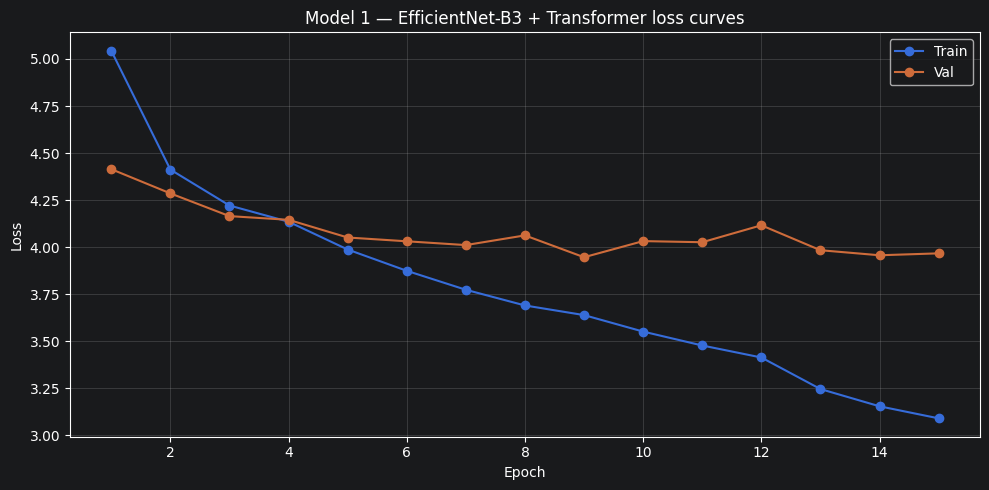

In [10]:
if CSV_M1.exists():
    plot_losses_from_csv(CSV_M1, "Model 1 — EfficientNet-B3 + Transformer loss curves")
elif history_m1:
    plot_loss_curves(history_m1, "Model 1 — EfficientNet-B3 + Transformer loss curves")
else:
    print("No loss history — run training first.")

### 7.3 Model 1 — BLEU evaluation

Loaded: /Users/rohanchaudhary/projects/DL_AT3/checkpoints/model1_best.pt

>>> BLEU M1 val [beam=5] (full)


BLEU val:   0%|          | 0/37 [00:00<?, ?batch/s]

  Decoded 1162 images
  val BLEU-1: 0.5331
  val BLEU-2: 0.3426
  val BLEU-3: 0.2289
  val BLEU-4: 0.1523

>>> BLEU M1 test [beam=5] (full)


BLEU test:   0%|          | 0/37 [00:00<?, ?batch/s]

  Decoded 1163 images
  test BLEU-1: 0.5367
  test BLEU-2: 0.3413
  test BLEU-3: 0.2243
  test BLEU-4: 0.1482
Saved model1_bleu.json


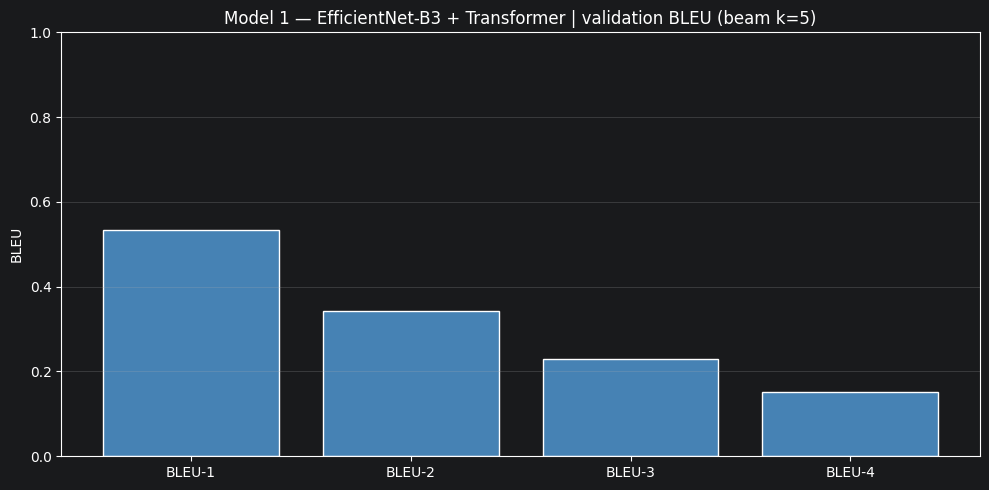

In [11]:
load_best_weights(model1, CKPT_M1)

bleu_m1_val  = evaluate_bleu(model1, val_loader,  "val",  BEAM_WIDTH, "M1")
bleu_m1_test = evaluate_bleu(model1, test_loader, "test", BEAM_WIDTH, "M1")

with open(RESULTS_DIR/"model1_bleu.json","w") as f:
    json.dump({"val_beam":bleu_m1_val,"test_beam":bleu_m1_test}, f, indent=2)
print("Saved model1_bleu.json")

plot_bleu_scores(bleu_m1_val, "Model 1 — EfficientNet-B3 + Transformer | validation BLEU (beam k=5)")

### 7.4 Model 1 — qualitative samples

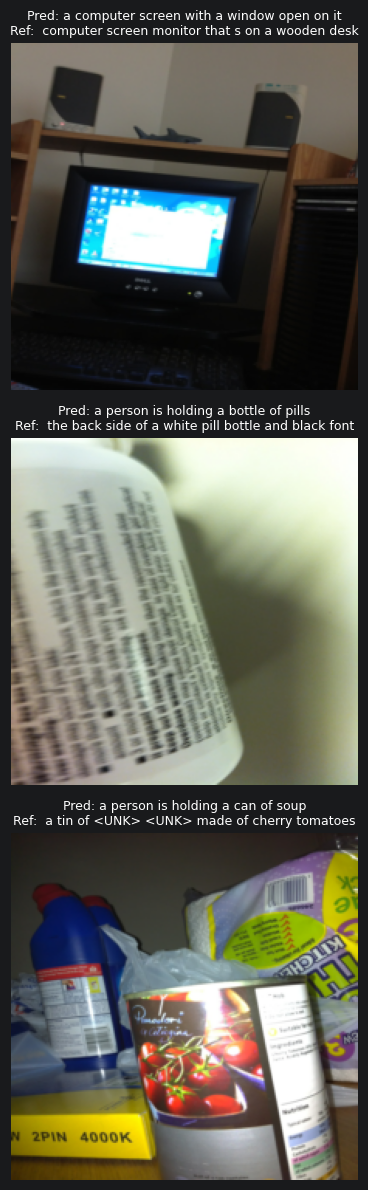

  [1] a computer screen with a window open on it
  [2] a person is holding a bottle of pills
  [3] a person is holding a can of soup
  [4] a close up of a computer screen with a blue background
  [5] a bottle of <UNK> <UNK> <UNK> <UNK> <UNK> <UNK> <UNK> <UNK> <UNK>
Model 1 Unique: 27/30


In [12]:
show_prediction_samples(model1, val_loader, vocab, n=3)
check_prediction_diversity(model1, val_loader, n=30, tag="Model 1")

## 8. Phase 3 — Model 2: VGG-16-BN + GRU

Phase 3 explores a simpler VGG-16-BN + 2-layer GRU architecture as a comparison point.
The global pooled encoder compresses spatial information into a single 512-d vector,
and the GRU decodes sequentially without cross-attention to image regions.
Comparing against Model 1 reveals the impact of spatial features and attention mechanisms.

In [13]:
EPOCHS_M2    = 1 if QUICK_TEST else 35
LR_DEC_M2    = 4e-4
LR_ENC_M2    = 1e-4
FREEZE_M2    = 2
CSV_M2       = RESULTS_DIR / "model2_losses.csv"
CKPT_M2      = CHECKPOINTS_DIR / "model2_best.pt"

model2 = CaptionModelPhase3(
    vocab_size=len(vocab), pad_idx=PAD_IDX,
    dropout=0.5, embed_dim=256, hidden_dim=512,
).to(DEVICE)

print(model2.ARCH_NAME)
total_m2 = sum(p.numel() for p in model2.parameters())
print(f"Parameters: {total_m2/1e6:.2f}M")

VGG-16-BN global (512-d) + 2-layer GRU decoder
Parameters: 20.52M


### 8.1 Train Model 2 (VGG-16-BN + GRU)

In [14]:
skip_m2 = not FORCE_RETRAIN_M2 and CKPT_M2.exists()

if skip_m2:
    print(f"Skipping Model 2 training — loading {CKPT_M2.name}")
    load_best_weights(model2, CKPT_M2)
    history_m2 = pd.read_csv(CSV_M2).to_dict("records") if CSV_M2.exists() else []
else:
    history_m2, _ = train_model(
        model2, train_loader, val_loss_loader,
        epochs=EPOCHS_M2, lr=LR_DEC_M2,
        csv_path=CSV_M2, model_label="Model 2",
        checkpoint_path=CKPT_M2,
        freeze_encoder_epochs=FREEZE_M2,
        encoder_lr=LR_ENC_M2,
        early_stop_patience=5,
    )
    load_best_weights(model2, CKPT_M2)

test_loss_m2 = evaluate_test_split(model2, test_loss_loader, "Model 2")
torch.save(model2.state_dict(), RESULTS_DIR/"model2_weights.pt")
print("Saved:", RESULTS_DIR/"model2_weights.pt")

Skipping Model 2 training — loading model2_best.pt
Loaded: /Users/rohanchaudhary/projects/DL_AT3/checkpoints/model2_best.pt

>>> Model 2 — final test loss


[Model 2] 1/1 test:   0%|          | 0/37 [00:00<?, ?batch/s]

  Test loss: 4.0175
Saved: /Users/rohanchaudhary/projects/DL_AT3/results/model2_weights.pt


### 8.2 Model 2 — loss curves

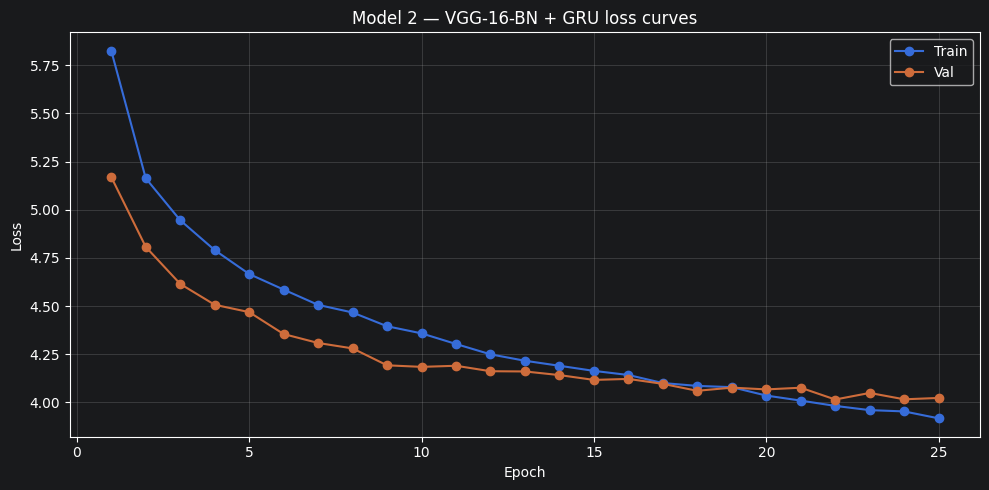

In [15]:
if CSV_M2.exists():
    plot_losses_from_csv(CSV_M2, "Model 2 — VGG-16-BN + GRU loss curves")
elif history_m2:
    plot_loss_curves(history_m2, "Model 2 — VGG-16-BN + GRU loss curves")
else:
    print("No loss history — run training first.")

### 8.3 Model 2 — BLEU evaluation

Loaded: /Users/rohanchaudhary/projects/DL_AT3/checkpoints/model2_best.pt

>>> BLEU M2 val [beam=5] (full)


BLEU val:   0%|          | 0/37 [00:00<?, ?batch/s]

  Decoded 1162 images
  val BLEU-1: 0.5863
  val BLEU-2: 0.3938
  val BLEU-3: 0.2626
  val BLEU-4: 0.1737

>>> BLEU M2 test [beam=5] (full)


BLEU test:   0%|          | 0/37 [00:00<?, ?batch/s]

  Decoded 1163 images
  test BLEU-1: 0.5897
  test BLEU-2: 0.3913
  test BLEU-3: 0.2554
  test BLEU-4: 0.1685
Saved model2_bleu.json


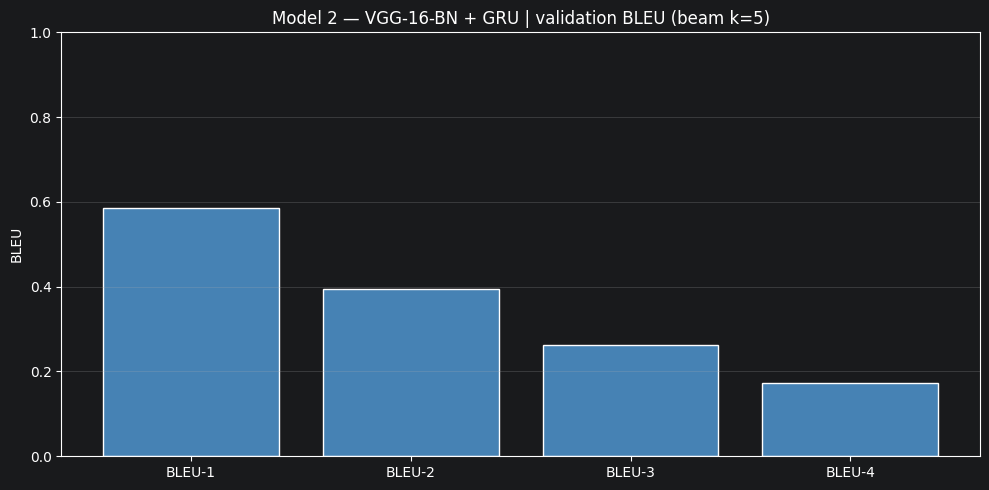

In [16]:
load_best_weights(model2, CKPT_M2)

bleu_m2_val  = evaluate_bleu(model2, val_loader,  "val",  BEAM_WIDTH, "M2")
bleu_m2_test = evaluate_bleu(model2, test_loader, "test", BEAM_WIDTH, "M2")

with open(RESULTS_DIR/"model2_bleu.json","w") as f:
    json.dump({"val_beam":bleu_m2_val,"test_beam":bleu_m2_test}, f, indent=2)
print("Saved model2_bleu.json")

plot_bleu_scores(bleu_m2_val, "Model 2 — VGG-16-BN + GRU | validation BLEU (beam k=5)")

### 8.4 Model 2 — qualitative samples

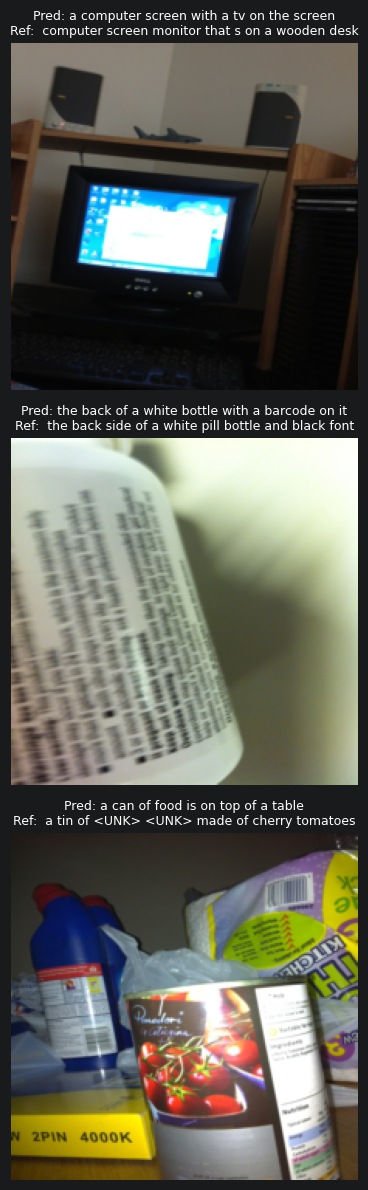

  [1] a computer screen with a tv on the screen
  [2] the back of a white bottle with a barcode on it
  [3] a can of food is on top of a table
  [4] a very wonderful view and worth seeing at all times my friend
  [5] a bottle of wine is on top of a table
Model 2 Unique: 28/30


In [17]:
show_prediction_samples(model2, val_loader, vocab, n=3)
check_prediction_diversity(model2, val_loader, n=30, tag="Model 2")

## 9. Comparison: Model 1 vs Model 2

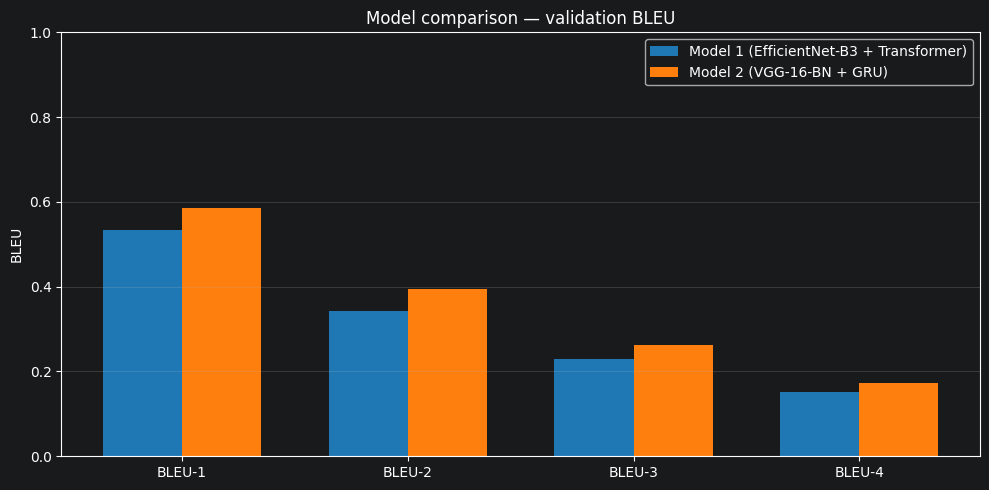

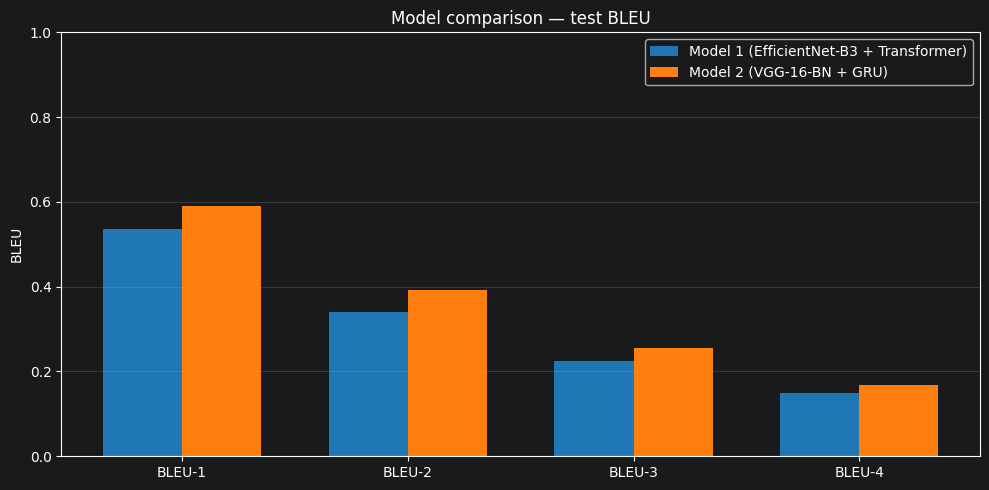

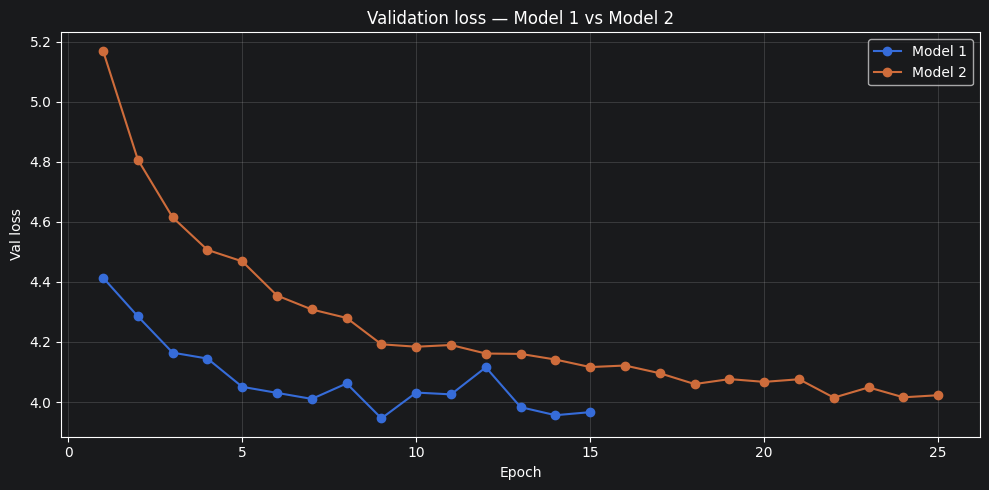

In [18]:
if "bleu_m1_val" not in dir():
    p = RESULTS_DIR/"model1_bleu.json"
    if p.exists(): bleu_m1_val = json.load(open(p))["val_beam"]
if "bleu_m1_test" not in dir():
    p = RESULTS_DIR/"model1_bleu.json"
    if p.exists(): bleu_m1_test = json.load(open(p))["test_beam"]
if "bleu_m2_val" not in dir():
    p = RESULTS_DIR/"model2_bleu.json"
    if p.exists(): bleu_m2_val = json.load(open(p))["val_beam"]
if "bleu_m2_test" not in dir():
    p = RESULTS_DIR/"model2_bleu.json"
    if p.exists(): bleu_m2_test = json.load(open(p))["test_beam"]

plot_model_comparison(bleu_m1_val, bleu_m2_val, "validation")
plot_model_comparison(bleu_m1_test, bleu_m2_test, "test")

if CSV_M1.exists() and CSV_M2.exists():
    plot_val_loss_comparison(CSV_M1, CSV_M2)

### 9.1 Summary table

In [19]:
comparison_df = pd.DataFrame({
    "Metric":                          ["BLEU-1","BLEU-2","BLEU-3","BLEU-4"],
    "M1 val  (EfficientNet, beam k=5)":[bleu_m1_val.get(f"BLEU-{i}",0)  for i in range(1,5)],
    "M1 test (EfficientNet, beam k=5)":[bleu_m1_test.get(f"BLEU-{i}",0) for i in range(1,5)],
    "M2 val  (VGG-GRU, beam k=5)":    [bleu_m2_val.get(f"BLEU-{i}",0)  for i in range(1,5)],
    "M2 test (VGG-GRU, beam k=5)":    [bleu_m2_test.get(f"BLEU-{i}",0) for i in range(1,5)],
})
print(comparison_df.round(4).to_string(index=False))
comparison_df.round(4).to_csv(RESULTS_DIR/"comparison_table.csv", index=False)
print("\nSaved comparison_table.csv")

Metric  M1 val  (EfficientNet, beam k=5)  M1 test (EfficientNet, beam k=5)  M2 val  (VGG-GRU, beam k=5)  M2 test (VGG-GRU, beam k=5)
BLEU-1                            0.5331                            0.5367                       0.5863                       0.5897
BLEU-2                            0.3426                            0.3413                       0.3938                       0.3913
BLEU-3                            0.2289                            0.2243                       0.2626                       0.2554
BLEU-4                            0.1523                            0.1482                       0.1737                       0.1685

Saved comparison_table.csv
